# Практика. Тензорное исчисление и автоматическое дифференцирование
---

## Цели работы
1. Научиться создавать и преобразовывать тензоры в PyTorch.
2. Понять механизм broadcasting и выполнять базовые линейно-алгебраические операции.
3. Вычислить градиент простой функции аналитически и сравнить с результатом `autograd`.
4. Исследовать вычислительный граф на примере более сложной функции.

---

## Повторение (на пальцах 🖐️)

- **Тензор** — это просто многомерный массив. Скаляр (0D), вектор (1D), матрица (2D), кубик (3D) и дальше — сколько угодно измерений.
- **Broadcasting** — умное растягивание меньшего тензора под размер большего при выполнении операций (как когда вы на вечеринке растягиваете историю, чтобы её слушали все).
- **Градиент** — вектор частных производных. Показывает направление наискорейшего роста функции. В машинном обучении мы идём **против** градиента, чтобы уменьшить ошибку.
- **Autograd** — встроенный в PyTorch механизм автоматического дифференцирования. Он строит вычислительный граф и по команде `.backward()` раскручивает его в обратную сторону, заполняя градиенты.

Всё вспомнили? Поехали!

## Задание 1. Основы тензорных операций

**Цель:** освоиться с созданием, индексацией, broadcasting и линейной алгеброй в PyTorch.

Импортируйте PyTorch (и NumPy, если потребуется) и выполните следующие пункты. Пишите код в ячейках ниже.

1. Создайте:
   - скаляр со значением 3.14;
   - вектор из чисел от 0 до 99;
   - матрицу 3×3, заполненную единицами;
   - тензор размера 2×3×4, заполненный случайными числами из стандартного нормального распределения (используйте `torch.randn`).
2. Создайте две случайные матрицы 5×5 и сложите их поэлементно.
3. Создайте матрицу 3×4 и вектор длины 4. Выполните матричное умножение (используйте `@` или `torch.mm`). Что получилось? Какой размер у результата?
4. Создайте вектор `v = torch.tensor([1, 2, 3])` и матрицу `m = torch.tensor([[[10, 20, 30], [40, 50, 60]],[[10, 20, 30], [40, 50, 60]]])`. Сложите их (`v + m`). Объясните, как сработал broadcasting.
5. Создайте тензор формы (1, 24). Измените его форму на (3, 8) с помощью `.view()`. Что произойдёт, если вы попытаетесь изменить на (2, 13)? Проверьте и зафиксируйте ошибку.

*Подсказка:* размерности можно проверять через `.shape`.

**Выводы по заданию 1:** (напишите в Markdown-ячейке после кода)

In [12]:
# Ваш код для задания 1
import torch
import numpy as np

# 1. Создание тензоров
scalar = torch.tensor(3.14)
vector = torch.tensor(list(range(0, 100)))
matrix_ones = torch.tensor(np.ones((3, 3)))
tensor_randn = torch.randn(2, 3, 4)

# 2. Случайные матрицы и сложение
A = torch.randn(5,5)
B = torch.randn(5,5)
C = A + B

# 3. Матричное умножение
M = torch.randn(3,4)
v = torch.randn(4)
result = M @ v
print(result.shape)

# 4. Broadcasting
v = torch.tensor([1,2,3])
m = torch.tensor([[[10, 20, 30], [40, 50, 60]], [[10, 20, 30], [40, 50, 60]]])
sum_bc = v + m
print(sum_bc)

# 5. Изменение формы
x = torch.randn(1,24)
x_reshaped = x.view((3, 8))
print(x_reshaped.shape)

torch.Size([3])
tensor([[[11, 22, 33],
         [41, 52, 63]],

        [[11, 22, 33],
         [41, 52, 63]]])
torch.Size([3, 8])


In [13]:
x.view(2,13)

RuntimeError: shape '[2, 13]' is invalid for input of size 24

### Место для выводов по заданию 1
1. Все получилось без проблем
2. Все получилось без проблем
3. Получился вектор длины 3
4. Broadcasting применил сложение к каждой строке матрицы отдельно, то есть не как обычное матричное сложение (где размеры должны совпадать)
5. Если изменить размер на (2, 13) будет ошибка: shape '[2, 13]' is invalid for input of size 24.

## Задание 2. Ручной расчёт градиента и проверка autograd

**Цель:** убедиться, что autograd не врёт, и заодно вспомнить частные производные.

Рассмотрим функцию двух переменных (сразу смотрите функцию из бонусного варианта):
$$
f(x, y) = x^2 y + y^3
$$

1. Аналитически найдите частные производные и вычислите градиент в точке $x = 2, y = 3$. Запишите ответы (можно прямо в Markdown).
2. Создайте тензоры `x` и `y` с `requires_grad=True`, инициализировав их значениями 2 и 3.
3. Вычислите `f` и вызовите `backward()`.
4. Распечатайте `x.grad` и `y.grad`. Сравните с аналитическим расчётом.
5. **Бонус:** измените функцию, например, добавьте синус: $f = x^2 y + \sin(y)$. Повторите вычисления аналитически и через autograd.

*Подсказка:* аналитически: $\partial f/\partial x = 2xy$, $\partial f/\partial y = x^2 + 3y^2$. При (2,3): (12, 4+27=31).

In [4]:
# Ваш код для задания 2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

f = x**2 * y + y**3
f.backward()

print("Градиент по x:", x.grad)
print("Градиент по y:", y.grad)

# Бонус:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

# Функция с синусом
f_sin = x**2 * y + torch.sin(y)
f_sin.backward()

print("\nБонус:")
print("Градиент по x:", x.grad)
print("Градиент по y:", y.grad)

Градиент по x: tensor(12.)
Градиент по y: tensor(31.)

Бонус:
Градиент по x: tensor(12.)
Градиент по y: tensor(3.0100)


### Выводы по заданию 2
Аналитический расчёт совпадает с программным:
- Для функции x^2 y + y^3 значение (x, y) составило (12, 31)
- Для бонусной функции с синусом f = x^2 y + \sin(y) (x, y) составил значение (12, 4 + cos(3)). 4 + cos(3) равен около 3.01

## Задание 3. Исследование вычислительного графа

**Цель:** научиться отслеживать промежуточные узлы графа и понимать, откуда берутся градиенты.

Дана функция:
$$
L = (\mathbf{a} \cdot \mathbf{b} + c)^2
$$
где $\mathbf{a}, \mathbf{b}$ — векторы длины 3, $c$ — скаляр, а $\cdot$ — скалярное произведение (можно использовать `torch.dot`).

1. Задайте конкретные значения: `a = torch.tensor([1., 2., 3.], requires_grad=True)`, `b = torch.tensor([4., 5., 6.], requires_grad=True)`, `c = torch.tensor([7.], requires_grad=True)`.
2. Вычислите `L`.
3. Вызовите `backward()` и выведите градиенты по `a`, `b`, `c`.
4. Попробуйте объяснить, почему градиент по `a` именно такой. Для этого можно:
   - Вспомнить, что скалярное произведение — это сумма поэлементных произведений.
   - Записать формулу явно и взять производную по каждому компоненту.
5. (Бонус) Выведите значение промежуточного узла: `s = torch.dot(a, b) + c` и его градиент (можно получить, если сохранить его и вызвать ` s.retain_grad()  s.backward()`, но аккуратно с повторным вызовом).

**Важно:** перед повторным вызовом backward нужно обнулить градиенты, иначе они накопятся. Используйте `.zero_()`.

In [11]:
# Ваш код для задания 3
a = torch.tensor([1.,2.,3.], requires_grad=True)
b = torch.tensor([4., 5., 6.], requires_grad=True)
c = torch.tensor([7.], requires_grad=True)

s = torch.dot(a, b) + c
L = s ** 2

L.backward()

print("grad a:", a.grad)
print("grad b:", b.grad)
print("grad c:", c.grad)

# Бонус: получите градиент для s (сначала обнулите, если нужно)
a.grad.zero_()
b.grad.zero_()
c.grad.zero_()

s = torch.dot(a, b) + c
s.retain_grad()
L = s**2

L.backward()

print(f"Значение узла s: {s.item()}")
print(f"Градиент для s: {s.grad}")

grad a: tensor([312., 390., 468.])
grad b: tensor([ 78., 156., 234.])
grad c: tensor([78.])
Значение узла s: 39.0
Градиент для s: tensor([78.])


### Выводы по заданию 3
Считаем градиент аналитически:

dL/da = (dL/ds) * (ds/da) = 2s * b

dL/db = (dL/ds) * (ds/db) = 2s * a

dL/dc = (dL/ds) * (ds/dc) = 2s * 1


s = a * b + c

s = 39

dL/da = 78 * b = 78 * (4, 5, 6) = (312, 390, 468)

dL/db = 78 * a = 78 * (1, 2, 3) = (78, 156, 234)

dL/dc = 78 * 1 = 78

dL/ds = 2s = `78`

Получили 78, как и было получено ранее

## Задание 4. Линейная регрессия с autograd

**Цель:** применить autograd для обучения простой модели.

Сгенерируйте данные:
$$y_{\text{true}} = -5 x + 12 + \text{шум}$$
для 200 точек x от -10 до 10.

Инициализируйте случайные параметры `w` и `b` с `requires_grad=True`. Напишите цикл обучения на 100 эпох:
- оценка целевой функции `y_pred = w * x + b`;
- функция потерь: RMSE (`((y_pred - y_true)**2).mean()`) (добавить корень);
- `loss.backward()`;
- обновление весов вручную (без оптимизатора): `w.data -= lr * w.grad`, `b.data -= lr * b.grad` (используйте `.data` или блок `torch.no_grad()`);
- обнуление градиентов.

Выведите итоговые параметры и постройте
1. График изменения loss с увеличением эпох;
2. Линейные графики исходной и полученной функций;
3. График самой функции loss и движение поиска минимума по ней.

*Подсказка:* не забудьте обнулять градиенты после каждого шага.

Это задание повторяет пример из лекции — попробуйте выполнить его без подглядывания, а потом сверьтесь.

Результат: w = 2.409, b = 1.870


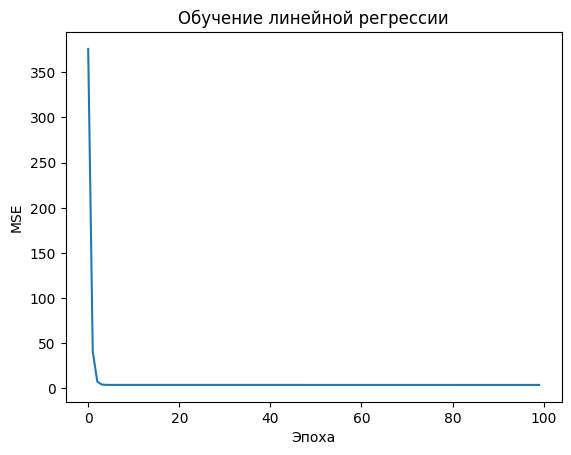

In [14]:
# Ваш код для задания 4
import matplotlib.pyplot as plt

# Генерация данных
x_true = torch.linspace(0, 10, 100)
y_true = 2.5 * x_true + 1.3 + torch.randn_like(x_true) * 2.0

# Инициализация параметров
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.01
loss_history = []

for epoch in range(100):
    # Прямой проход
    y_pred = w * x_true + b
    loss = ((y_pred - y_true)**2).mean()
    loss_history.append(loss.item())
    
    # Обратный проход
    loss.backward()

    # Обновление весов
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Обнуление градиентов
    w.grad.zero_()
    b.grad.zero_()

print(f"Результат: w = {w.item():.3f}, b = {b.item():.3f}")

plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение линейной регрессии")
plt.show()

### Выводы по заданию 4

Модель обучить получилось, проблем не было

## Заключение

Поздравляю, вы пережили первое практическое занятие! Теперь вы умеете:
- создавать тензоры любой размерности;
- использовать broadcasting;
- считать градиенты вручную и доверять autograd;
- строить простые вычислительные графы.

Эти навыки пригодятся уже на следующем занятии, когда мы будем визуализировать градиентный спуск. Если остались вопросы — не стесняйтесь задавать (и да, чат с одногруппниками тоже работает).

**Сдавайте выполненную работу в виде этого блокнота с заполненными ячейками и выводами.**

Успехов!